### Análisis de datos II
## Clustering
### Evaluación y comparación (ARI, AMI)

https://scikit-learn.org/stable/api/sklearn.metrics.html

Esta notebook ejemplifica las métricas de evaluación y comparación usando como referencia K-means entrenado con datos sintéticos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score

In [2]:
# Generamos un dataset sintético de ejemplo (los mismos de la notebook de Estabilidad)
from sklearn.datasets import make_blobs
K=5
X, y_true = make_blobs(n_samples=600, centers=K, cluster_std=2.0, random_state=42)
X.shape

(600, 2)

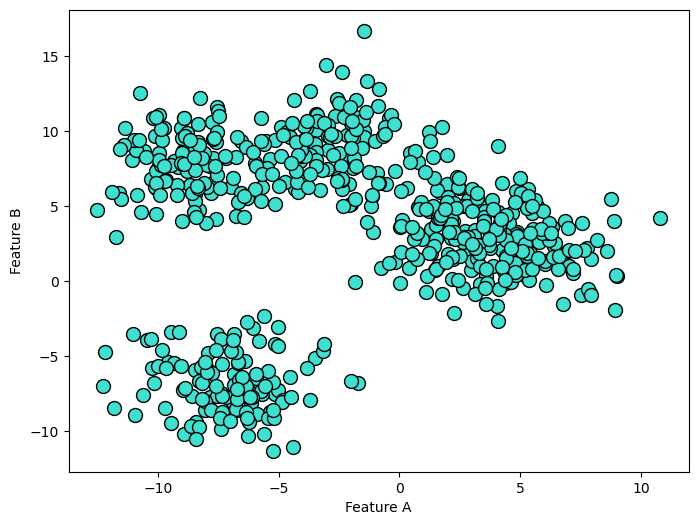

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(X[:, 0], X[:, 1],
                "o",
                markerfacecolor='turquoise',
                markeredgecolor="k",
                markersize=10)
plt.xlabel("Feature A")
plt.ylabel("Feature B")
plt.show()

#### Vamos a entrenar K-means para distintos valores de K.

In [4]:
from sklearn.cluster import KMeans

# 2. Escenario A: Un buen clustering (K-Means con k=5)
kmeans_good = KMeans(n_clusters=5, random_state=42, n_init=10)
y_pred_good = kmeans_good.fit_predict(X)

# 3. Escenario B: Un mal clustering (K-Means forzado con k=3)
kmeans_bad = KMeans(n_clusters=3, random_state=42, n_init=10)
y_pred_bad = kmeans_bad.fit_predict(X)

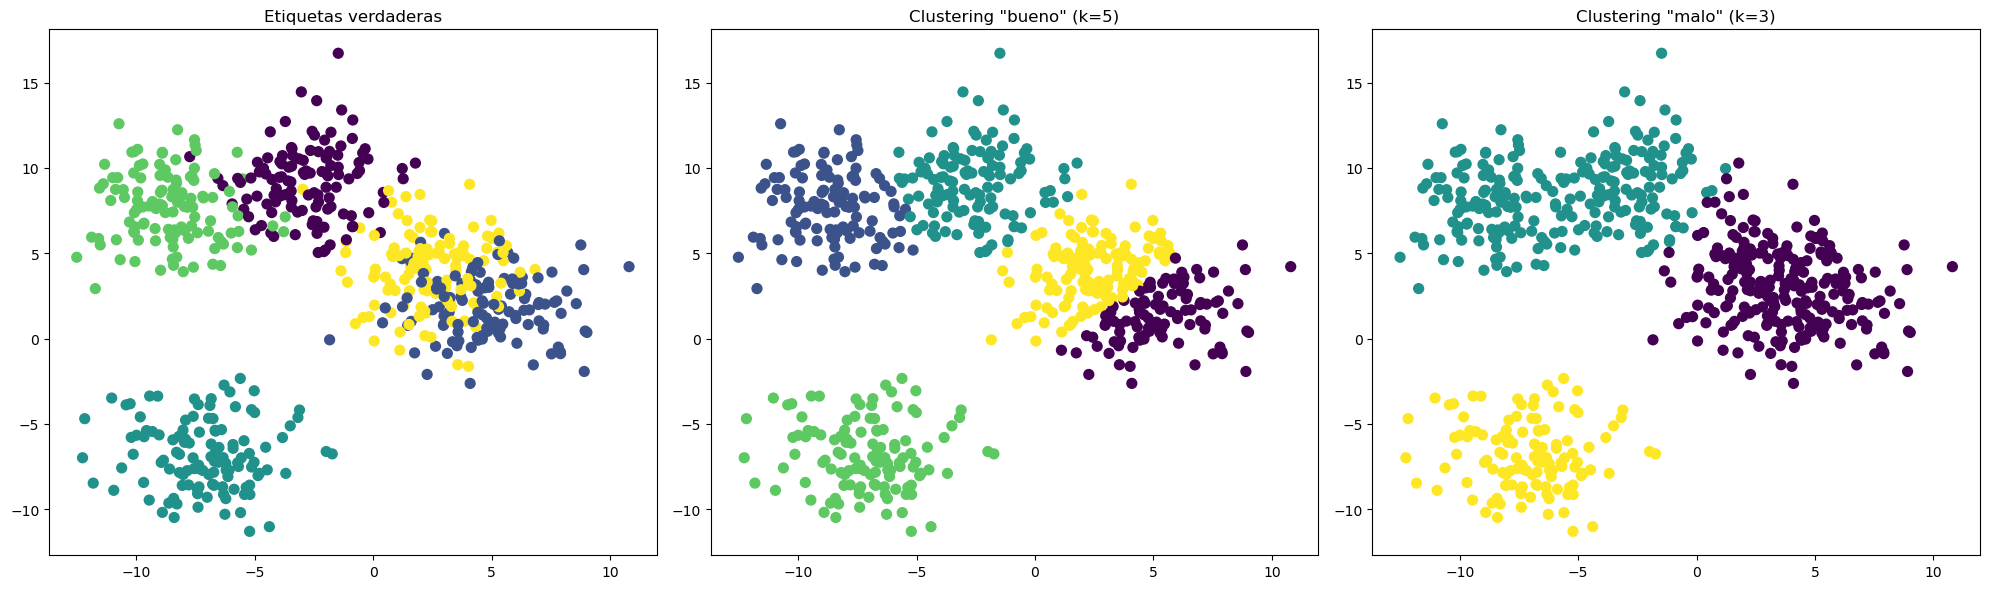

In [5]:
# Visualizamos los resultados lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico del etiquetas verdaderas (las que creamos al generar los datos sintéticos)
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=50)
axes[0].set_title('Etiquetas verdaderas', fontsize=12)

# Gráfico del clustering 'bueno'
axes[1].scatter(X[:, 0], X[:, 1], c=y_pred_good, cmap='viridis', s=50)
axes[1].set_title('Clustering "bueno" (k=5)', fontsize=12)

# Gráfico del clustering 'malo'
axes[2].scatter(X[:, 0], X[:, 1], c=y_pred_bad, cmap='viridis', s=50)
axes[2].set_title(f'Clustering "malo" (k=3)', fontsize=12)

plt.tight_layout()
plt.show()

### adjusted_rand_score (ARI)

Con ARI podemos comparar clusters vs. etiquetas reales.

Su valor máximo es 1:

- 1 → coincidencia perfecta
- 0 → coincidencia equivalente a lo esperable por azar
- valores negativos → peor que azar

In [6]:
# Calculamos ARI
ari_good = adjusted_rand_score(y_true, y_pred_good)
ari_bad = adjusted_rand_score(y_true, y_pred_bad)

print(f"ARI del clustering bueno vs. etiquetas reales: {ari_good:.3f}")
print(f"ARI del clustering malo vs. etiquetas reales: {ari_bad:.3f}")

ARI del clustering bueno vs. etiquetas reales: 0.762
ARI del clustering malo vs. etiquetas reales: 0.586


ARI = 0.76, en el caso de k=3, indica que hay una alta coincidencia entre el resultado del clustering "bueno" y las etiquetas reales.

### adjusted_mutual_info_score (AMI)

AMI es similar al ARI, pero basada en la teoría de la información (mide cuánta "información" comparten los clusters con las etiquetas reales):

- 0 → ninguna relación
- 1 → correspondencia perfecta

In [7]:
# Calculamos AMI
ami_good = adjusted_mutual_info_score(y_true, y_pred_good)
ami_bad = adjusted_mutual_info_score(y_true, y_pred_bad)

print(f"AMI del clustering bueno vs. etiquetas reales: {ami_good:.3f}")
print(f"AMI del clustering malo vs. etiquetas reales: {ami_bad:.3f}")

AMI del clustering bueno vs. etiquetas reales: 0.794
AMI del clustering malo vs. etiquetas reales: 0.743


En ambos casos, AMI indica que hay bastante información compartida entre el clustering y las etiquetas reales.

### Comparación de dos modelos con ARI y AMI

Con ARI y AMI también podemos comparar el resultado de dos modelos entre sí.

In [8]:
ari_good_vs_bad = adjusted_rand_score(y_pred_good, y_pred_bad)
ami_good_vs_bad = adjusted_mutual_info_score(y_pred_good, y_pred_bad)

print(f"ARI del clustering bueno vs. el clustering malo: {ari_good_vs_bad:.3f}")
print(f"AMI del clustering bueno vs. el clustering malo: {ami_good_vs_bad:.3f}")

ARI del clustering bueno vs. el clustering malo: 0.602
AMI del clustering bueno vs. el clustering malo: 0.766


**OBSERVACIONES**

Ambos modelos comparten cierta consistencia. Por ejemplo, hay un cluster que es idéntico en los dos resultados.

El ARI cuenta pares de puntos y castiga cada par de puntos sin correspondencia. Dada la cantidad de puntos que no se corresponde, el resultado da 0.6.

El AMI detecta que, aunque se hayan fusionado algunos clusters, la estructura general sigue compartiendo mucha información mutua sobre dónde están concentrados los datos. Por eso el valor da bastante alto, aún cuando ni siquiera coincide la cantidad de clusters entre los dos algoritmos.